In [1]:
# %pip install -U pandas requests tqdm rapidfuzz countryinfo

import os, re, json, time, math, hashlib, itertools
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Tuple

import pandas as pd
import requests
from tqdm.auto import tqdm

# similarity (opzionale, migliora il match title/year)
try:
    from rapidfuzz.fuzz import token_set_ratio as _token_set_ratio
except Exception:
    _token_set_ratio = None

from countryinfo import CountryInfo
import pycountry


In [2]:
# -----------------------------
# CONFIG
# -----------------------------
INPUT_CSV = Path("../data/processed/dataset_clean.csv")
OUT_DIR   = Path("../data/processed/outputs/openalex_notebook_outputs")

MAILTO = "4847306@studenti.unige.it"   
RESOLVE_TITLE_YEAR = True            
TITLE_YEAR_THRESHOLD = 92.0           

# rate limit 
MIN_INTERVAL_SEC = 0.12  # ~8 req/s

OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_WORKS_DIR = OUT_DIR / "cache_openalex_works"
CACHE_INST_DIR  = OUT_DIR / "cache_openalex_institutions"
CACHE_WORKS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_INST_DIR.mkdir(parents=True, exist_ok=True)

print("Input:", INPUT_CSV.resolve())
print("Out  :", OUT_DIR.resolve())


Input: /Users/irynasavchuk/Desktop/DATAVIZ_PROJECT/DV/dv_repo/data/processed/dataset_clean.csv
Out  : /Users/irynasavchuk/Desktop/DATAVIZ_PROJECT/DV/dv_repo/data/processed/outputs/openalex_notebook_outputs


In [3]:
# -----------------------------
# HELPERS: parsing / normalizzazioni
# -----------------------------
_DOI_RE = re.compile(r"(10\.\d{4,9}/[-._;()/:A-Z0-9]+)", re.IGNORECASE)

def normalize_doi(raw: Any) -> Optional[str]:
    """Ritorna DOI normalizzato (lowercase) o None."""
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return None
    s = str(raw).strip()
    if not s:
        return None
    s = s.replace("https://doi.org/", "").replace("http://doi.org/", "")
    s = s.replace("https://dx.doi.org/", "").replace("http://dx.doi.org/", "")
    s = s.replace("doi:", "").strip()
    m = _DOI_RE.search(s)
    if not m:
        return None
    doi = m.group(1).strip().lower()
    if doi.startswith("10.0000"):  # placeholder
        return None
    return doi

def split_semicolon_list(raw: Any) -> List[str]:
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return []
    s = str(raw).strip()
    if not s:
        return []
    return [p.strip() for p in s.split(";") if p.strip()]

def norm_space(s: str) -> str:
    return re.sub(r"\s+", " ", (s or "").strip())

def normalize_author_name(name: str) -> str:
    """Normalizzazione *solo testuale* (fallback quando non c'è OpenAlex ID)."""
    n = norm_space(name)
    # se formato "Cognome, Nome" -> "Nome Cognome"
    if "," in n and len(n.split(",")) == 2:
        last, first = [p.strip() for p in n.split(",", 1)]
        if first and last:
            n = f"{first} {last}"
    # rimuovi doppie spaziature, punteggiatura ridondante ai bordi
    n = re.sub(r"[\s\-]+", " ", n).strip()
    # Title Case semplice (mantiene iniziali)
    n = " ".join([w if w.isupper() and len(w) <= 3 else w.capitalize() for w in n.split(" ")])
    return n

def stable_local_author_id(canonical_name: str) -> str:
    """ID locale deterministico basato su nome canonicalizzato (può collidere per omonimi)."""
    key = canonical_name.strip().lower().encode("utf-8", errors="ignore")
    h = hashlib.sha1(key).hexdigest()[:16]
    return f"local:{h}"

def short_openalex_id(url_or_id: Optional[str]) -> Optional[str]:
    if not url_or_id:
        return None
    s = str(url_or_id).strip()
    return s.replace("https://openalex.org/", "")

def token_set_ratio(a: str, b: str) -> float:
    a = a or ""
    b = b or ""
    if _token_set_ratio is not None:
        return float(_token_set_ratio(a, b))
    import difflib
    return difflib.SequenceMatcher(None, a.lower(), b.lower()).ratio() * 100.0

def safe_json_dumps(x: Any) -> str:
    return json.dumps(x, ensure_ascii=False)

def safe_json_loads(x: Any) -> Any:
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return None
    if isinstance(x, (dict, list)):
        return x
    try:
        return json.loads(x)
    except Exception:
        return None

def country_name_from_code(cc: Optional[str]) -> Optional[str]:
    if not cc:
        return None
    try:
        c = pycountry.countries.get(alpha_2=cc)
        return c.name if c else None
    except Exception:
        return None

def world_region_from_country_code(cc: Optional[str]) -> Optional[str]:
    """Ritorna macro-regione (continent) usando countryinfo, se possibile."""
    name = country_name_from_code(cc)
    if not name:
        return None
    try:
        info = CountryInfo(name).info()
        # countryinfo usa 'region' (es: 'Europe', 'Asia', ...)
        return info.get("region") or None
    except Exception:
        return None


def is_placeholder_doi(doi: Optional[str]) -> bool:
    return bool(doi) and str(doi).strip().lower().startswith("10.0000")

def normalize_doi_keep_placeholder(raw: Any) -> Optional[str]:
    '''
    Come normalize_doi(), ma NON scarta i DOI placeholder 10.0000...
    Utile perché nel tuo dataset questi DOI fake sono comunque univoci e quindi
    possono essere usati come identificatore del paper (work_id).
    '''
    if raw is None or (isinstance(raw, float) and pd.isna(raw)):
        return None
    s = str(raw).strip()
    if not s:
        return None

    s = s.replace("https://doi.org/", "").replace("http://doi.org/", "")
    s = s.replace("https://dx.doi.org/", "").replace("http://dx.doi.org/", "")
    s = s.replace("doi:", "").strip()

    m = _DOI_RE.search(s)
    if not m:
        return None
    return m.group(1).strip().lower()


In [4]:
# -----------------------------
# OpenAlex client con cache + rate limit + retry
# -----------------------------
class OpenAlexClient:
    def __init__(self, mailto: str, cache_works_dir: Path, cache_inst_dir: Path, min_interval_sec: float = 0.12):
        self.mailto = mailto
        self.cache_works_dir = Path(cache_works_dir)
        self.cache_inst_dir  = Path(cache_inst_dir)
        self.session = requests.Session()
        self.min_interval_sec = float(min_interval_sec)
        self._last_call_ts = 0.0

    def _sleep_if_needed(self):
        dt = time.time() - self._last_call_ts
        if dt < self.min_interval_sec:
            time.sleep(self.min_interval_sec - dt)

    def _cache_path(self, kind: str, key: str) -> Path:
        h = hashlib.sha1(key.encode("utf-8")).hexdigest()
        if kind == "work":
            return self.cache_works_dir / f"{h}.json"
        if kind == "inst":
            return self.cache_inst_dir / f"{h}.json"
        raise ValueError("Unknown cache kind")

    def _get(self, url: str, params: Optional[Dict[str, Any]] = None, timeout: int = 30) -> requests.Response:
        self._sleep_if_needed()
        params = dict(params or {})
        if self.mailto:
            params.setdefault("mailto", self.mailto)
        resp = self.session.get(url, params=params, timeout=timeout, headers={"User-Agent": "vispub-openalex-notebook/1.0"})
        self._last_call_ts = time.time()
        return resp

    def get_work_by_doi(self, doi: str) -> Tuple[Optional[Dict[str, Any]], str]:
        doi = normalize_doi(doi) or ""
        if not doi:
            return None, "no_doi"

        key = f"work_by_doi::{doi}"
        cp = self._cache_path("work", key)
        if cp.exists():
            try:
                return json.loads(cp.read_text(encoding="utf-8")), "ok_cache"
            except Exception:
                pass

        url = f"https://api.openalex.org/works/https://doi.org/{doi}"
        for attempt in range(5):
            try:
                r = self._get(url)
                if r.status_code == 200:
                    data = r.json()
                    cp.write_text(json.dumps(data, ensure_ascii=False), encoding="utf-8")
                    return data, "ok"
                if r.status_code == 404:
                    return None, "not_found"
                if r.status_code in (429, 500, 502, 503, 504):
                    time.sleep(0.7 * (attempt + 1))
                    continue
                return None, f"error_http_{r.status_code}"
            except Exception:
                time.sleep(0.7 * (attempt + 1))
                continue
        return None, "error"

    def search_work_by_title_year(self, title: str, year: int, per_page: int = 10) -> Tuple[List[Dict[str, Any]], str]:
        title = (title or "").strip()
        if not title or not year:
            return [], "bad_args"

        key = f"search::{year}::{title}"
        cp = self._cache_path("work", key)
        if cp.exists():
            try:
                return json.loads(cp.read_text(encoding="utf-8")), "ok_cache"
            except Exception:
                pass

        url = "https://api.openalex.org/works"
        params = {"search": title, "filter": f"publication_year:{int(year)}", "per_page": int(per_page)}
        for attempt in range(5):
            try:
                r = self._get(url, params=params)
                if r.status_code == 200:
                    results = (r.json() or {}).get("results", []) or []
                    cp.write_text(json.dumps(results, ensure_ascii=False), encoding="utf-8")
                    return results, "ok"
                if r.status_code in (429, 500, 502, 503, 504):
                    time.sleep(0.7 * (attempt + 1))
                    continue
                return [], f"error_http_{r.status_code}"
            except Exception:
                time.sleep(0.7 * (attempt + 1))
                continue
        return [], "error"

    def get_institution(self, inst_id: str) -> Tuple[Optional[Dict[str, Any]], str]:
        inst_id = short_openalex_id(inst_id) or str(inst_id)
        if not inst_id.startswith("I"):
            return None, "bad_inst_id"

        key = f"institution::{inst_id}"
        cp = self._cache_path("inst", key)
        if cp.exists():
            try:
                return json.loads(cp.read_text(encoding="utf-8")), "ok_cache"
            except Exception:
                pass

        url = f"https://api.openalex.org/institutions/{inst_id}"
        for attempt in range(5):
            try:
                r = self._get(url)
                if r.status_code == 200:
                    data = r.json()
                    cp.write_text(json.dumps(data, ensure_ascii=False), encoding="utf-8")
                    return data, "ok"
                if r.status_code == 404:
                    return None, "not_found"
                if r.status_code in (429, 500, 502, 503, 504):
                    time.sleep(0.7 * (attempt + 1))
                    continue
                return None, f"error_http_{r.status_code}"
            except Exception:
                time.sleep(0.7 * (attempt + 1))
                continue
        return None, "error"


client = OpenAlexClient(
    mailto=MAILTO,
    cache_works_dir=CACHE_WORKS_DIR,
    cache_inst_dir=CACHE_INST_DIR,
    min_interval_sec=MIN_INTERVAL_SEC
)


In [5]:
# -----------------------------
# 1) LOAD DATASET + normalizzazioni base
# -----------------------------
df = pd.read_csv(INPUT_CSV)

# Year -> int (se possibile)
if "Year" in df.columns:
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")

# DOI normalizzato (chiave work_id)
df["doi_unique"] = df["DOI"].apply(normalize_doi_keep_placeholder)
df["doi_for_openalex"] = df["DOI"].apply(normalize_doi)  # scarta placeholder 10.0000...
df["doi_normalized"] = df["doi_unique"]  # compat: usalo come ID/chiave paper
# work_id: preferisci DOI, altrimenti hash titolo+anno (fallback)
# work_id: preferisci DOI, altrimenti hash titolo+anno (fallback)
def make_work_id(row: pd.Series, idx: int) -> str:
    doi = row.get("doi_unique")
    if isinstance(doi, str) and doi:
        return doi
    base = f"{row.get('Conference','')}//{row.get('Year','')}//{row.get('Title','')}"
    h = hashlib.sha1(base.encode("utf-8", errors="ignore")).hexdigest()[:16]
    return f"no_doi:{h}"

df["work_id"] = [make_work_id(r, i) for i, r in df.iterrows()]

print("Rows:", len(df))
print("With DOI (unique IDs incl. placeholder):", df["doi_unique"].notna().sum())
print("With DOI queryable on OpenAlex:", df["doi_for_openalex"].notna().sum())
df.head(2)


Rows: 3530
With DOI (unique IDs incl. placeholder): 3530
With DOI queryable on OpenAlex: 3530


,Conference,Year,Title,DOI,PaperType,Abstract,AuthorNames-Deduped,AuthorAffiliation,InternalReferences,AuthorKeywords,...,Cluster,MacroCategory,MacroSlug,ClusterShort,ClusterSlug,ClusterFileSlug,doi_unique,doi_for_openalex,doi_normalized,work_id
0,Vis,2024,Interactive Design-of-Experiments: Optimizing ...,10.1109/tvcg.2024.3456356,J,The optimization of cooling systems is importa...,Rainer Splechtna;Majid Behravan;Mario Jelovic;...,"VRVis Research Center in Vienna, Austria;Virgi...",10.1109/tvcg.2013.124;10.1109/tvcg.2008.145;10...,Parameter space exploration,...,8,Dimensionality Reduction & Multivariate Plots,dimensionality-reduction-multivariate,Diffusion MRI & Tractography,diffusion-mri-tractography,t08-diffusion-mri,10.1109/tvcg.2024.3456356,10.1109/tvcg.2024.3456356,10.1109/tvcg.2024.3456356,10.1109/tvcg.2024.3456356
1,Vis,2024,Towards Dataset-Scale and Feature-Oriented Eva...,10.1109/tvcg.2024.3456398,J,Recent advancements in Large Language Models (...,Sam Yu-Te Lee;Aryaman Bahukhandi;Dongyu Liu;Kw...,"University of California, USA;University of Ca...",10.1109/tvcg.2017.2743858;10.1109/tvcg.2017.27...,"Visual analytics,prompt engineering,,,text sum...",...,2,Dimensionality Reduction & Multivariate Plots,dimensionality-reduction-multivariate,Flow Fields & Vortices (CFD),flow-fields-vortices-cfd,t02-flow-fields-vortices,10.1109/tvcg.2024.3456398,10.1109/tvcg.2024.3456398,10.1109/tvcg.2024.3456398,10.1109/tvcg.2024.3456398


In [6]:
# -----------------------------
# 2) RESOLVE WORKS + BUILD authorships/authors
# -----------------------------
works_rows: List[Dict[str, Any]] = []
authorships_rows: List[Dict[str, Any]] = []
authors_map: Dict[str, Dict[str, Any]] = {}   # author_id -> author row

unresolved_rows: List[Dict[str, Any]] = []
ambiguous_rows: List[Dict[str, Any]] = []

def pick_best_candidate_by_title(title: str, candidates: List[Dict[str, Any]], threshold: float = 92.0) -> Tuple[Optional[Dict[str, Any]], float]:
    best, best_score = None, -1.0
    for c in candidates:
        t = c.get("title") or ""
        score = token_set_ratio(title, t)
        if score > best_score:
            best, best_score = c, score
    if best is None:
        return None, 0.0
    if best_score >= threshold:
        return best, best_score
    return None, best_score

# Output "pulito" per il dataset: nomi canonicali e affiliazioni canonicali (allineate)
clean_author_names: List[str] = []
clean_affiliations: List[str] = []

for idx, row in tqdm(df.iterrows(), total=len(df), desc="OpenAlex resolve"):
    title = str(row.get("Title") or "").strip()
    year  = int(row["Year"]) if not pd.isna(row.get("Year")) else None
    doi_unique = row.get("doi_unique")
    doi_query  = row.get("doi_for_openalex")
    work_id = row["work_id"]

    openalex_work = None
    matched_by = "none"
    title_year_score = None
    openalex_status = None

    # 1) DOI lookup
    if isinstance(doi_query, str) and doi_query:
        openalex_work, openalex_status = client.get_work_by_doi(doi_query)
        if openalex_work:
            matched_by = "doi"

    # 2) (opzionale) Title+Year search
    if openalex_work is None and RESOLVE_TITLE_YEAR and title and year:
        candidates, st = client.search_work_by_title_year(title=title, year=year, per_page=10)
        if st.startswith("ok") and candidates:
            best, score = pick_best_candidate_by_title(title, candidates, threshold=TITLE_YEAR_THRESHOLD)
            title_year_score = score
            if best is not None and best.get("id"):
                # fetch full record by OpenAlex work id
                wid = best["id"]  # https://openalex.org/W...
                url = wid.replace("https://openalex.org/", "https://api.openalex.org/works/")
                try:
                    r = client._get(url)
                    if r.status_code == 200:
                        openalex_work = r.json()
                        matched_by = "title_year"
                except Exception:
                    pass
            else:
                # salva per review manuale se score è vicino
                if score >= (TITLE_YEAR_THRESHOLD - 5) and candidates:
                    top = candidates[0]
                    ambiguous_rows.append({
                        "work_id": work_id,
                        "Title": title,
                        "Year": year,
                        "best_score": score,
                        "best_candidate_id": top.get("id"),
                        "best_candidate_title": top.get("title"),
                    })

    # --- works row (copio tutte le colonne originali + arricchimento)
    w = {c: row.get(c) for c in df.columns}
    if openalex_work:
        w.update({
            "openalex_work_id": short_openalex_id(openalex_work.get("id")),
            "openalex_work_id_url": openalex_work.get("id"),
            "openalex_cited_by_count": openalex_work.get("cited_by_count"),
            "openalex_publication_date": openalex_work.get("publication_date"),
            "openalex_primary_location": safe_json_dumps(openalex_work.get("primary_location") or {}),
            "openalex_host_venue": safe_json_dumps(openalex_work.get("host_venue") or {}),
        })
    else:
        w.update({
            "openalex_work_id": None,
            "openalex_work_id_url": None,
            "openalex_cited_by_count": None,
            "openalex_publication_date": None,
            "openalex_primary_location": None,
            "openalex_host_venue": None,
        })

    w.update({
        "matched_by": matched_by,
        "title_year_score": title_year_score,
        "openalex_status": openalex_status,
    })
    works_rows.append(w)

    # --- authorships
    if openalex_work:
        auths = openalex_work.get("authorships", []) or []

        # Per dataset pulito: usa OpenAlex display_name, in ordine
        names_for_paper = []
        affs_for_paper  = []

        for pos, a in enumerate(auths, start=1):
            author = a.get("author") or {}
            author_id_url = author.get("id")
            author_id = short_openalex_id(author_id_url) or stable_local_author_id(normalize_author_name(author.get("display_name") or f"unknown_{pos}"))

            display_name = author.get("display_name") or ""
            canonical_name = normalize_author_name(display_name) if display_name else display_name

            # upsert author
            if author_id not in authors_map:
                authors_map[author_id] = {
                    "author_id": author_id,
                    "openalex_author_id_url": author_id_url,
                    "display_name": canonical_name or display_name,
                    "orcid": author.get("orcid"),
                    "source": "openalex" if (author_id and str(author_id).startswith("A")) else "mixed",
                }

            # institutions (può essere lista)
            insts = a.get("institutions", []) or []
            inst_ids, inst_names, inst_cc, inst_ror = [], [], [], []
            for inst in insts:
                iid = short_openalex_id(inst.get("id"))
                if iid:
                    inst_ids.append(iid)
                inst_names.append(inst.get("display_name"))
                inst_cc.append(inst.get("country_code"))
                inst_ror.append(inst.get("ror"))

            # authorship row
            authorships_rows.append({
                "work_id": work_id,
                "doi": doi_unique,
                "doi_query": doi_query,
                "author_id": author_id,
                "author_position": pos,
                "author_display_name": canonical_name or display_name,
                "institutions_openalex_ids": safe_json_dumps(inst_ids),
                "institutions_names": safe_json_dumps(inst_names),
                "institutions_country_codes": safe_json_dumps(inst_cc),
                "institutions_ror": safe_json_dumps(inst_ror),
                "from_openalex": True,
            })

            names_for_paper.append(canonical_name or display_name or "")
            # affiliazioni allineate: per autore una stringa, eventuali multiple separate da ' | '
            inst_names_clean = [norm_space(x or "") for x in inst_names if x]
            affs_for_paper.append(" | ".join(inst_names_clean) if inst_names_clean else "")

        clean_author_names.append(";".join([n for n in names_for_paper if n]))
        clean_affiliations.append(";".join([a for a in affs_for_paper if a]) if any(affs_for_paper) else "")

    else:
        # fallback: usa solo dataset (AuthorNames-Deduped + AuthorAffiliation)
        raw_names = split_semicolon_list(row.get("AuthorNames-Deduped")) or split_semicolon_list(row.get("AuthorNames"))
        raw_affs  = split_semicolon_list(row.get("AuthorAffiliation"))

        names_for_paper = [normalize_author_name(n) for n in raw_names]

        # allinea affiliazioni se conteggi combaciano, altrimenti stringhe vuote
        if raw_affs and len(raw_affs) == len(names_for_paper):
            affs_for_paper = [norm_space(a) for a in raw_affs]
        else:
            affs_for_paper = [""] * len(names_for_paper)

        for pos, (nm, aff) in enumerate(zip(names_for_paper, affs_for_paper), start=1):
            if not nm:
                continue
            author_id = stable_local_author_id(nm)

            if author_id not in authors_map:
                authors_map[author_id] = {
                    "author_id": author_id,
                    "openalex_author_id_url": None,
                    "display_name": nm,
                    "orcid": None,
                    "source": "local",
                }

            authorships_rows.append({
                "work_id": work_id,
                "doi": doi_unique,
                "doi_query": doi_query,
                "author_id": author_id,
                "author_position": pos,
                "author_display_name": nm,
                "institutions_openalex_ids": safe_json_dumps([]),
                "institutions_names": safe_json_dumps([]),
                "institutions_country_codes": safe_json_dumps([]),
                "institutions_ror": safe_json_dumps([]),
                "affiliation_raw": aff,
                "from_openalex": False,
            })

        clean_author_names.append(";".join([n for n in names_for_paper if n]))
        clean_affiliations.append(";".join([a for a in affs_for_paper if a]) if any(affs_for_paper) else "")

        unresolved_rows.append({
            "work_id": work_id,
            "doi": doi_unique,
                "doi_query": doi_query,
            "Title": title,
            "Year": year,
            "reason": "openalex_not_found_or_no_doi",
        })

# aggiungi colonne "pulite" al dataset
df["AuthorNames-Deduped-Clean"] = clean_author_names
df["AuthorAffiliation-Clean"]   = clean_affiliations

works_df = pd.DataFrame(works_rows)
authorships_df = pd.DataFrame(authorships_rows)
authors_df = pd.DataFrame(list(authors_map.values()))
unresolved_df = pd.DataFrame(unresolved_rows).drop_duplicates()
ambiguous_df  = pd.DataFrame(ambiguous_rows).drop_duplicates()

print("Works:", len(works_df))
print("Authorships:", len(authorships_df))
print("Authors:", len(authors_df))
print("Unresolved works:", len(unresolved_df))


OpenAlex resolve:   0%|          | 0/3530 [00:00<?, ?it/s]

Works: 3530
Authorships: 14189
Authors: 7200
Unresolved works: 0


In [7]:
# -----------------------------
# 3) WRITE BASE OUTPUTS
# -----------------------------
(OUT_DIR / "tables").mkdir(exist_ok=True, parents=True)

works_path       = OUT_DIR / "tables" / "works_enriched.csv"
authors_path     = OUT_DIR / "tables" / "authors.csv"
authorships_path = OUT_DIR / "tables" / "authorships.csv"
clean_dataset    = OUT_DIR / "tables" / "dataset_clean_with_openalex.csv"
unresolved_path  = OUT_DIR / "tables" / "unresolved_works.csv"
ambiguous_path   = OUT_DIR / "tables" / "ambiguous_matches.csv"

works_df.to_csv(works_path, index=False)
authors_df.to_csv(authors_path, index=False)
authorships_df.to_csv(authorships_path, index=False)
df.to_csv(clean_dataset, index=False)
unresolved_df.to_csv(unresolved_path, index=False)
ambiguous_df.to_csv(ambiguous_path, index=False)

print("Wrote:", works_path)
print("Wrote:", authors_path)
print("Wrote:", authorships_path)
print("Wrote:", clean_dataset)


Wrote: ../data/processed/outputs/openalex_notebook_outputs/tables/works_enriched.csv
Wrote: ../data/processed/outputs/openalex_notebook_outputs/tables/authors.csv
Wrote: ../data/processed/outputs/openalex_notebook_outputs/tables/authorships.csv
Wrote: ../data/processed/outputs/openalex_notebook_outputs/tables/dataset_clean_with_openalex.csv


In [8]:
# -----------------------------
# 4) COAUTHOR NETWORK (author ↔ author)
#    weight = n_papers insieme
#    doi_list = lista DOI condivisi
# -----------------------------
edge_counts: Dict[Tuple[str, str], Dict[str, Any]] = {}

for work_id, g in authorships_df.groupby("work_id"):
    ids = list(g["author_id"].dropna().astype(str))
    ids = sorted(set([i for i in ids if i]))
    if len(ids) < 2:
        continue
    doi = g["doi"].dropna().astype(str).iloc[0] if g["doi"].notna().any() else None

    for a, b in itertools.combinations(ids, 2):
        key = (a, b)
        if key not in edge_counts:
            edge_counts[key] = {"author_id_1": a, "author_id_2": b, "weight": 0, "doi_list": []}
        edge_counts[key]["weight"] += 1
        if doi:
            edge_counts[key]["doi_list"].append(doi)

coauthor_edges_df = pd.DataFrame(list(edge_counts.values()))
if not coauthor_edges_df.empty:
    coauthor_edges_df["doi_list"] = coauthor_edges_df["doi_list"].apply(safe_json_dumps)
    coauthor_edges_df = coauthor_edges_df.sort_values(["weight", "author_id_1", "author_id_2"], ascending=[False, True, True])

coauthor_edges_path = OUT_DIR / "tables" / "coauthor_edges.csv"
coauthor_edges_df.to_csv(coauthor_edges_path, index=False)
print("Wrote:", coauthor_edges_path)
coauthor_edges_df.head()


Wrote: ../data/processed/outputs/openalex_notebook_outputs/tables/coauthor_edges.csv


,author_id_1,author_id_2,weight,doi_list
2414,A5010238198,A5043151044,23,"[""10.1109/tvcg.2009.178"", ""10.1109/tvcg.2012.2..."
1062,A5009460413,A5019902487,20,"[""10.1109/tvcg.2006.186"", ""10.1109/tvcg.2007.7..."
3242,A5022699013,A5057538550,15,"[""10.1109/tvcg.2011.181"", ""10.1109/tvcg.2012.2..."
917,A5008149778,A5085695563,14,"[""10.1109/tvcg.2006.156"", ""10.1109/tvcg.2008.1..."
8396,A5036489223,A5068526974,14,"[""10.1109/tvcg.2017.2745859"", ""10.1109/tvcg.20..."


In [9]:
# -----------------------------
# 5) INSTITUTIONS TABLE (con geo lat/lon, country, world region)
# -----------------------------
def explode_inst_ids(authorships_df: pd.DataFrame) -> pd.DataFrame:
    tmp = authorships_df.copy()
    tmp["inst_ids"] = tmp["institutions_openalex_ids"].apply(lambda x: safe_json_loads(x) or [])
    tmp = tmp.explode("inst_ids").rename(columns={"inst_ids": "institution_id"})
    tmp = tmp[tmp["institution_id"].notna()]
    tmp["institution_id"] = tmp["institution_id"].astype(str)
    tmp = tmp[tmp["institution_id"].str.startswith("I")]
    return tmp

inst_long = explode_inst_ids(authorships_df)
unique_inst_ids = sorted(inst_long["institution_id"].unique().tolist())
print("Unique OpenAlex institutions:", len(unique_inst_ids))

inst_rows = []
for iid in tqdm(unique_inst_ids, desc="Fetch institutions"):
    inst, st = client.get_institution(iid)
    if not inst:
        continue

    geo = inst.get("geo") or {}
    cc = inst.get("country_code")
    inst_rows.append({
        "institution_id": short_openalex_id(inst.get("id")) or iid,
        "display_name": inst.get("display_name"),
        "ror": inst.get("ror"),
        "type": inst.get("type"),
        "country_code": cc,
        "country_name": country_name_from_code(cc),
        "world_region": world_region_from_country_code(cc),
        "city": geo.get("city"),
        "region": geo.get("region"),
        "latitude": geo.get("latitude"),
        "longitude": geo.get("longitude"),
        "homepage_url": inst.get("homepage_url"),
        "works_count_openalex": inst.get("works_count"),
        "cited_by_count_openalex": inst.get("cited_by_count"),
    })

institutions_df = pd.DataFrame(inst_rows).drop_duplicates(subset=["institution_id"])
institutions_path = OUT_DIR / "tables" / "institutions.csv"
institutions_df.to_csv(institutions_path, index=False)
print("Wrote:", institutions_path)

institutions_df.head()


Unique OpenAlex institutions: 1162


Fetch institutions:   0%|          | 0/1162 [00:00<?, ?it/s]

Wrote: ../data/processed/outputs/openalex_notebook_outputs/tables/institutions.csv


,institution_id,display_name,ror,type,country_code,country_name,world_region,city,region,latitude,longitude,homepage_url,works_count_openalex,cited_by_count_openalex
0,I100005738,Brigham Young University,https://ror.org/047rhhm47,education,US,United States,Americas,Provo,None,40.233841,-111.658531,https://www.byu.edu,67070,3564056
1,I100066346,University of Stuttgart,https://ror.org/04vnq7t77,education,DE,Germany,Europe,Stuttgart,None,48.782318,9.177020,http://www.uni-stuttgart.de/home/index.en.html,150663,4957524
2,I100296615,École Nationale de l’Aviation Civile,https://ror.org/022zdgq74,education,FR,France,Europe,Toulouse,None,43.604259,1.443670,http://www.enac.fr/,3695,56574
3,I100532134,Université Claude Bernard Lyon 1,https://ror.org/029brtt94,education,FR,France,Europe,Villeurbanne,None,45.766010,4.879500,http://www.univ-lyon1.fr/home-759942.kjsp,179439,15301694
4,I100621029,Bank of America,https://ror.org/006tvg625,other,US,United States,Americas,Charlotte,North Carolina,35.226852,-80.842110,https://www.bankofamerica.com/,1028,27021


In [10]:
# -----------------------------
# 6) INSTITUTION COLLAB NETWORK (institution ↔ institution)
# -----------------------------
inst_edge_counts: Dict[Tuple[str, str], Dict[str, Any]] = {}

# work -> istituzioni (uniche) presenti sul paper
work_to_insts = (inst_long.groupby("work_id")["institution_id"]
                 .apply(lambda x: sorted(set([i for i in x if isinstance(i, str)])))
                 .to_dict())

# work -> doi
work_to_doi = (authorships_df.groupby("work_id")["doi"]
               .apply(lambda x: x.dropna().astype(str).iloc[0] if x.dropna().shape[0] else None)
               .to_dict())

for work_id, insts in work_to_insts.items():
    insts = [i for i in insts if i]
    if len(insts) < 2:
        continue
    doi = work_to_doi.get(work_id)
    for a, b in itertools.combinations(insts, 2):
        key = (a, b)
        if key not in inst_edge_counts:
            inst_edge_counts[key] = {"institution_id_1": a, "institution_id_2": b, "weight": 0, "doi_list": []}
        inst_edge_counts[key]["weight"] += 1
        if doi:
            inst_edge_counts[key]["doi_list"].append(doi)

inst_edges_df = pd.DataFrame(list(inst_edge_counts.values()))
if not inst_edges_df.empty:
    inst_edges_df["doi_list"] = inst_edges_df["doi_list"].apply(safe_json_dumps)
    inst_edges_df = inst_edges_df.sort_values(["weight", "institution_id_1", "institution_id_2"], ascending=[False, True, True])

inst_edges_path = OUT_DIR / "tables" / "institution_edges.csv"
inst_edges_df.to_csv(inst_edges_path, index=False)
print("Wrote:", inst_edges_path)
inst_edges_df.head()


Wrote: ../data/processed/outputs/openalex_notebook_outputs/tables/institution_edges.csv


,institution_id_1,institution_id_2,weight,doi_list
173,I200769079,I889458895,98,"[""10.1109/tvcg.2007.70523"", ""10.1109/tvcg.2007..."
335,I1343190059,I145847075,33,"[""10.1109/tvcg.2009.110"", ""10.1109/tvcg.2009.1..."
3075,I1327163397,I59553526,32,"[""10.1109/visual.1990.146365"", ""10.1109/visual..."
138,I1282311441,I223532165,19,"[""10.1109/tvcg.2006.171"", ""10.1109/tvcg.2008.1..."
344,I200769079,I76130692,18,"[""10.1109/tvcg.2009.112"", ""10.1109/tvcg.2011.2..."


In [11]:
# -----------------------------
# 7) DERIVED DATASETS for SECTION 2 & 3
# -----------------------------

# --- per-work: n_authors
work_auth_counts = (authorships_df.groupby("work_id")["author_id"]
                    .nunique()
                    .reset_index(name="n_authors"))

works_basic = works_df[["work_id", "doi_normalized", "Year", "Award", "CitationCount_CrossRef", "openalex_cited_by_count",
                        "MacroCategory", "MacroSlug", "Cluster", "ClusterSlug"]].copy()

works_basic = works_basic.merge(work_auth_counts, on="work_id", how="left")

# citazioni: preferisci OpenAlex se disponibile, altrimenti CrossRef
def pick_citations(r):
    oa = r.get("openalex_cited_by_count")
    if pd.notna(oa):
        return float(oa)
    cr = r.get("CitationCount_CrossRef")
    if pd.notna(cr):
        return float(cr)
    return 0.0

works_basic["citations"] = works_basic.apply(pick_citations, axis=1)
works_basic["has_award"] = works_basic["Award"].apply(lambda x: 1 if (pd.notna(x) and str(x).strip()) else 0)

# =========================
# SECTION 2a: avg authors per paper by year (mean + std)
# =========================
sec2a = (works_basic.dropna(subset=["Year"])
         .groupby("Year")["n_authors"]
         .agg(mean_authors="mean", std_authors="std", min_authors="min", max_authors="max", n_papers="count")
         .reset_index()
         .sort_values("Year"))

sec2a_path = OUT_DIR / "tables" / "sec2a_authors_per_paper_by_year.csv"
sec2a.to_csv(sec2a_path, index=False)

# =========================
# SECTION 2b: unique authors cumulative by year
# =========================
# authors per year: usa authorships joinato all'anno del work
auth_year = authorships_df.merge(works_df[["work_id", "Year"]], on="work_id", how="left")
auth_year = auth_year.dropna(subset=["Year"])

unique_by_year = (auth_year.groupby("Year")["author_id"]
                  .nunique()
                  .reset_index(name="unique_authors_year")
                  .sort_values("Year"))

unique_by_year["unique_authors_cum"] = unique_by_year["unique_authors_year"].cumsum()

sec2b_path = OUT_DIR / "tables" / "sec2b_unique_authors_cumulative.csv"
unique_by_year.to_csv(sec2b_path, index=False)

# =========================
# SECTION 2d: author stats (papers, awards, citations) -> bubble chart
# =========================
# author -> papers list
author_work = (authorships_df.groupby("author_id")["work_id"]
               .apply(lambda x: sorted(set(x.astype(str))))
               .reset_index(name="work_ids"))

# join works info
aw = authorships_df[["author_id", "work_id"]].drop_duplicates().merge(
    works_basic[["work_id", "citations", "has_award"]], on="work_id", how="left"
)

author_stats = (aw.groupby("author_id")
                .agg(n_papers=("work_id", "nunique"),
                     total_citations=("citations", "sum"),
                     n_awards=("has_award", "sum"))
                .reset_index())

# list DOI per author
work_to_doi = works_df.set_index("work_id")["doi_normalized"].to_dict()
author_dois = (authorships_df.groupby("author_id")["work_id"]
               .apply(lambda xs: sorted({work_to_doi.get(w) for w in xs if work_to_doi.get(w)}))
               .reset_index(name="doi_list"))

author_dois["doi_list"] = author_dois["doi_list"].apply(safe_json_dumps)
author_stats = author_stats.merge(authors_df[["author_id", "display_name"]], on="author_id", how="left")
author_stats = author_stats.merge(author_dois, on="author_id", how="left")

sec2d_path = OUT_DIR / "tables" / "sec2d_author_stats.csv"
author_stats.to_csv(sec2d_path, index=False)

# =========================
# SECTION 3a: institutions map table (lat/lon + counts)
# =========================
# institution -> n_papers (nel tuo dataset)
inst_papers = (inst_long.groupby("institution_id")["work_id"]
               .nunique()
               .reset_index(name="n_papers_dataset"))

inst_authors = (inst_long.groupby("institution_id")["author_id"]
                .nunique()
                .reset_index(name="n_authors_dataset"))

sec3a = (institutions_df.merge(inst_papers, on="institution_id", how="left")
         .merge(inst_authors, on="institution_id", how="left"))

sec3a_path = OUT_DIR / "tables" / "sec3a_institutions_map.csv"
sec3a.to_csv(sec3a_path, index=False)

# =========================
# SECTION 3b: major topics per major institute (Sankey)
#   institution -> MacroCategory (o MacroSlug) con conteggi
# =========================
inst_work_topic = inst_long.merge(
    works_df[["work_id", "MacroCategory", "MacroSlug", "Cluster", "ClusterSlug", "doi_normalized"]],
    on="work_id", how="left"
)

sec3b = (inst_work_topic.dropna(subset=["MacroCategory"])
         .groupby(["institution_id", "MacroCategory"])
         .agg(n_papers=("work_id", "nunique"),
              doi_list=("doi_normalized", lambda x: sorted({d for d in x if isinstance(d, str) and d})))
         .reset_index())

sec3b["doi_list"] = sec3b["doi_list"].apply(safe_json_dumps)

sec3b_path = OUT_DIR / "tables" / "sec3b_institution_macrocategory_counts.csv"
sec3b.to_csv(sec3b_path, index=False)

# SECTION 3c: institution collaborations -> già in institution_edges.csv

print("Wrote:")
print("-", sec2a_path.name)
print("-", sec2b_path.name)
print("-", sec2d_path.name)
print("-", sec3a_path.name)
print("-", sec3b_path.name)

sec2a.head(), unique_by_year.head(), author_stats.head(), sec3a.head(), sec3b.head()


Wrote:
- sec2a_authors_per_paper_by_year.csv
- sec2b_unique_authors_cumulative.csv
- sec2d_author_stats.csv
- sec3a_institutions_map.csv
- sec3b_institution_macrocategory_counts.csv


(   Year  mean_authors  std_authors  min_authors  max_authors  n_papers
 0  1990      2.264151     1.332305            1            6        53
 1  1991      2.560000     1.387407            1            7        50
 2  1992      2.490566     1.825278            1           12        53
 3  1993      2.345455     1.308352            1            6        55
 4  1994      2.584906     1.486270            1            8        53,
    Year  unique_authors_year  unique_authors_cum
 0  1990                  119                 119
 1  1991                  126                 245
 2  1992                  125                 370
 3  1993                  123                 493
 4  1994                  134                 627,
      author_id  n_papers  total_citations  n_awards      display_name  \
 0  A1044056533         1             28.0         0  P. Samuel Quinan   
 1  A1208706714         1             31.0         0     Marlene Zawin   
 2   A130811099         1             17.0  

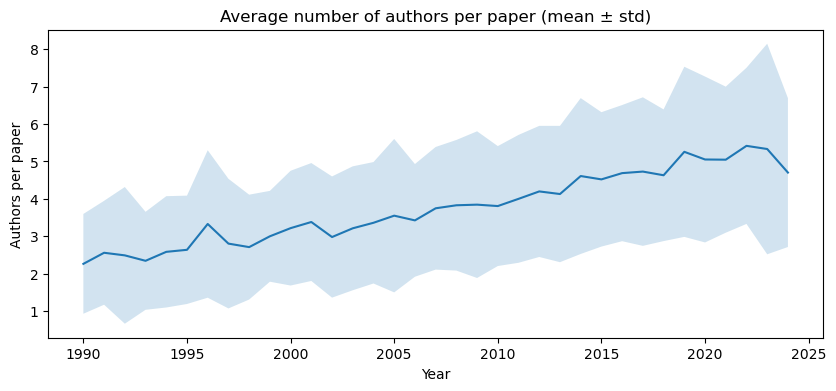

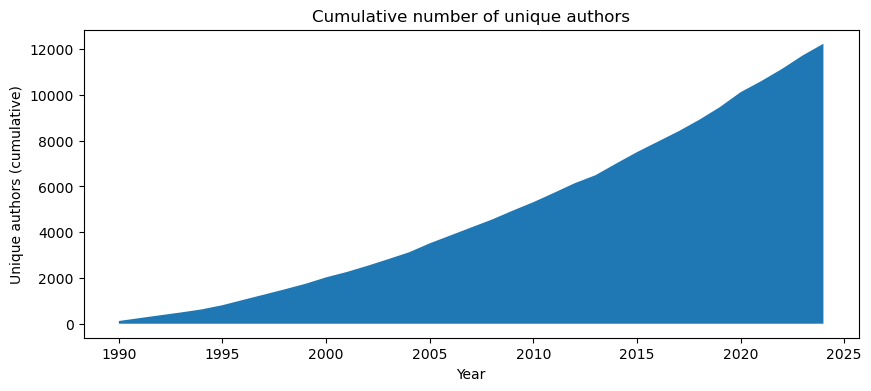

In [12]:
# -----------------------------
# (OPZIONALE) Quick plots dentro notebook
# -----------------------------
import matplotlib.pyplot as plt

# SECTION 2a line chart (mean + band std)
if not sec2a.empty:
    x = sec2a["Year"].astype(int).to_numpy()
    y = sec2a["mean_authors"].to_numpy()
    s = sec2a["std_authors"].fillna(0).to_numpy()

    plt.figure(figsize=(10,4))
    plt.plot(x, y)
    plt.fill_between(x, y - s, y + s, alpha=0.2)
    plt.title("Average number of authors per paper (mean ± std)")
    plt.xlabel("Year")
    plt.ylabel("Authors per paper")
    plt.show()

# SECTION 2b cumulative unique authors
if not unique_by_year.empty:
    plt.figure(figsize=(10,4))
    plt.fill_between(unique_by_year["Year"].astype(int), unique_by_year["unique_authors_cum"])
    plt.title("Cumulative number of unique authors")
    plt.xlabel("Year")
    plt.ylabel("Unique authors (cumulative)")
    plt.show()


In [13]:
# -----------------------------
# 8) REPORT (riassunto)
# -----------------------------
report = {
    "n_input_rows": int(len(df)),
    "n_works": int(len(works_df)),
    "n_authors": int(len(authors_df)),
    "n_authorships": int(len(authorships_df)),
    "n_coauthor_edges": int(len(coauthor_edges_df)),
    "n_institutions": int(len(institutions_df)),
    "n_institution_edges": int(len(inst_edges_df)),
    "paths": {
        "works_enriched": str(works_path),
        "authors": str(authors_path),
        "authorships": str(authorships_path),
        "coauthor_edges": str(coauthor_edges_path),
        "institutions": str(institutions_path),
        "institution_edges": str(inst_edges_path),
        "clean_dataset": str(clean_dataset),
    }
}

report_path = OUT_DIR / "tables" / "report.json"
report_path.write_text(json.dumps(report, ensure_ascii=False, indent=2), encoding="utf-8")
print("Wrote:", report_path)
report


Wrote: ../data/processed/outputs/openalex_notebook_outputs/tables/report.json


{'n_input_rows': 3530,
 'n_works': 3530,
 'n_authors': 7200,
 'n_authorships': 14189,
 'n_coauthor_edges': 23747,
 'n_institutions': 1161,
 'n_institution_edges': 3524,
 'paths': {'works_enriched': '../data/processed/outputs/openalex_notebook_outputs/tables/works_enriched.csv',
  'authors': '../data/processed/outputs/openalex_notebook_outputs/tables/authors.csv',
  'authorships': '../data/processed/outputs/openalex_notebook_outputs/tables/authorships.csv',
  'coauthor_edges': '../data/processed/outputs/openalex_notebook_outputs/tables/coauthor_edges.csv',
  'institutions': '../data/processed/outputs/openalex_notebook_outputs/tables/institutions.csv',
  'institution_edges': '../data/processed/outputs/openalex_notebook_outputs/tables/institution_edges.csv',
  'clean_dataset': '../data/processed/outputs/openalex_notebook_outputs/tables/dataset_clean_with_openalex.csv'}}